<a href="https://colab.research.google.com/github/shauryasachdev/Vizuara_CV/blob/main/U_Net.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# -------------------------------------------------------
# 1) Imports & Setup
# -------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Determine the device to use (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
from torchvision.datasets import OxfordIIITPet
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

# -------------------------------------------------------
# 3) Dataset & DataLoaders
# -------------------------------------------------------

# Define transforms
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

target_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

# Download the Oxford-IIIT Pet dataset (downloads automatically to /content/)
full_ds = OxfordIIITPet(
    root="/content/",
    split="trainval",
    target_types="segmentation",
    transform=transform,
    target_transform=target_transform,
    download=True           # <-- downloads automatically on first run
)

# Split into train and validation sets
val_size   = int(0.2 * len(full_ds))
train_size = len(full_ds) - val_size
train_ds, val_ds = random_split(full_ds, [train_size, val_size])

# Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train size: {len(train_ds)}, Val size: {len(val_ds)}")

100%|██████████| 792M/792M [00:37<00:00, 21.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.3MB/s]


Train size: 2944, Val size: 736


In [5]:
# -------------------------------------------------------
# 2) U-Net Model
# -------------------------------------------------------

# Define a Double Convolution block used in the U-Net
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        # Sequential container for two convolutional layers
        # with Batch Normalization and ReLU activation
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),   # First convolutional layer
            nn.BatchNorm2d(out_ch),                    # Batch normalization
            nn.ReLU(inplace=True),                     # ReLU activation
            nn.Conv2d(out_ch, out_ch, 3, padding=1),   # Second convolutional layer
            nn.BatchNorm2d(out_ch),                    # Batch normalization
            nn.ReLU(inplace=True),                     # ReLU activation
        )

    def forward(self, x):
        return self.net(x)  # Forward pass through the sequential layers


# Define a Downsampling block for the encoder part of U-Net
class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        # Sequential container for Max Pooling and a Double Convolution block
        self.net = nn.Sequential(
            nn.MaxPool2d(2),              # Max pooling reduces spatial dimensions
            DoubleConv(in_ch, out_ch)
        )

    def forward(self, x):
        return self.net(x)  # Forward pass


# Define an Upsampling block for the decoder part of U-Net
class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        # Transposed convolution (upsampling)
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        # Double Convolution block after upsampling and concatenation
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x1, x2):
        # x1 is the input from the previous upsampling layer
        # x2 is the skip connection from the corresponding encoder layer
        x1 = self.up(x1)
        # Pad to handle odd sizes
        diffY = x2.size(2) - x1.size(2)
        diffX = x2.size(3) - x1.size(3)
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                         diffY // 2, diffY - diffY // 2])  # Pad x1 to match spatial dims of x2
        x = torch.cat([x2, x1], dim=1)   # Concatenate x2 and padded x1 along channel dimension
        return self.conv(x)               # Forward pass through the Double Convolution block


# Define the U-Net model
class UNet(nn.Module):
    def __init__(self, in_ch=3, base=64):
        super().__init__()

        # Encoder part (downsampling path)
        self.inc   = DoubleConv(in_ch, base)          # Initial input convolution
        self.down1 = Down(base,    base * 2)           # First downsampling block
        self.down2 = Down(base*2,  base * 4)           # Second downsampling block
        self.down3 = Down(base*4,  base * 8)           # Third downsampling block
        self.down4 = Down(base*8,  base * 16)          # Fourth downsampling block (bottleneck)

        # Decoder part (upsampling path)
        self.up1 = Up(base*16, base*8)                 # First upsampling block
        self.up2 = Up(base*8,  base*4)                 # Second upsampling block
        self.up3 = Up(base*4,  base*2)                 # Third upsampling block
        self.up4 = Up(base*2,  base)                   # Fourth upsampling block

        # Output layer (1x1 convolution to get the final segmentation mask)
        self.outc = nn.Conv2d(base, 1, kernel_size=1)

    def forward(self, x):
        # Forward pass through the U-Net
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x  = self.up1(x5, x4)   # Upsample and concatenate with skip connection
        x  = self.up2(x,  x3)   # Upsample and concatenate with skip connection
        x  = self.up3(x,  x2)   # Upsample and concatenate with skip connection
        x  = self.up4(x,  x1)   # Upsample and concatenate with skip connection
        return self.outc(x)      # Final output convolution


# Create an instance of the UNet model and move it to the selected device
model = UNet().to(device)

In [6]:
# -------------------------------------------------------
# 3) Loss Functions & Metrics
# -------------------------------------------------------

# Define the Dice Loss function
class DiceLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps  # Small epsilon value to prevent division by zero

    def forward(self, logits, targets):
        # Apply sigmoid to the model's output logits to get probabilities
        probs = torch.sigmoid(logits)
        # Calculate the numerator of the Dice score (2 * intersection)
        num = 2 * (probs * targets).sum(dim=(2, 3)) + self.eps
        # Calculate the denominator of the Dice score (sum of areas)
        den = (probs * probs).sum(dim=(2, 3)) + (targets * targets).sum(dim=(2, 3)) + self.eps
        # Return the average Dice Loss (1 – Dice Score) over the batch
        return (1 - num / den).mean()


# Define the Binary Cross-Entropy with Logits loss
bce  = nn.BCEWithLogitsLoss()
# Create an instance of the Dice Loss
dice = DiceLoss()


# Define a combined loss function
def loss_fn(outputs, targets, alpha=0.5):
    # Combine BCE and Dice Loss with a weighting factor alpha
    return alpha * bce(outputs, targets) + (1 - alpha) * dice(outputs, targets)


# Define the Intersection over Union (IoU) score metric
def iou_score(outputs, targets, thr=0.5):
    # Apply sigmoid to get probabilities
    probs = torch.sigmoid(outputs)
    # Threshold probabilities to get binary predictions
    preds = (probs > thr).float()
    # Calculate the intersection between predictions and ground truth
    inter = (preds * targets).sum(dim=(2, 3))
    # Calculate the union between predictions and ground truth
    union = (preds + targets - preds * targets).sum(dim=(2, 3)) + 1e-6  # epsilon to avoid division by zero
    # Return the average IoU score over the batch
    return (inter / union).mean().item()


# Define the optimizer (AdamW) for updating model parameters
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
# Define the learning rate scheduler (Cosine Annealing)
# T_max is the number of epochs for the cosine cycle
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [7]:
# -------------------------------------------------------
# 4) Training Loop
# -------------------------------------------------------

EPOCHS = 10  # Number of training epochs (adjust upward for potentially better results)

best_val_iou = 0.0                            # Initialize the best validation IoU score
ckpt_path    = "/content/unet_oxfordpet.pth"  # Path to save the best model checkpoint

# NOTE: train_loader and val_loader must be defined before running this loop.
# Example (replace with your actual dataset/loaders):
#
#   from torchvision import datasets, transforms
#   from torch.utils.data import random_split
#   ...
#   train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=2)
#   val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=2)

# Loop over the specified number of epochs
for epoch in range(1, EPOCHS + 1):
    model.train()          # Set the model to training mode
    train_loss = 0.0       # Initialize training loss for the epoch

    # Create a progress bar for the training data loader
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]")

    # Iterate over batches in the training data loader
    for imgs, masks in pbar:
        # Move images and masks to the device (GPU or CPU)
        imgs  = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()                        # Zero the gradients of model parameters
        logits = model(imgs)                         # Perform a forward pass to get model outputs (logits)
        loss   = loss_fn(logits, masks)              # Calculate the loss
        loss.backward()                              # Perform backpropagation to calculate gradients
        optimizer.step()                             # Update model parameters using the optimizer

        train_loss += loss.item() * imgs.size(0)     # Accumulate training loss
        pbar.set_postfix(loss=float(loss))           # Update the progress bar with the current loss

    # ---- Validation ----
    model.eval()           # Set the model to evaluation mode
    val_loss = 0.0         # Initialize validation loss for the epoch
    val_iou  = 0.0         # Initialize validation IoU for the epoch

    with torch.no_grad():  # Disable gradient calculation for evaluation
        # Iterate over batches in the validation data loader
        for imgs, masks in val_loader:
            # Move images and masks to the device
            imgs  = imgs.to(device)
            masks = masks.to(device)

            logits    = model(imgs)                          # Perform a forward pass
            loss      = loss_fn(logits, masks)               # Calculate the loss
            val_loss += loss.item() * imgs.size(0)           # Accumulate validation loss
            val_iou  += iou_score(logits, masks) * imgs.size(0)

    # Normalise accumulated losses by dataset size
    train_loss /= len(train_loader.dataset)
    val_loss   /= len(val_loader.dataset)
    val_iou    /= len(val_loader.dataset)

    scheduler.step()  # Step the learning rate scheduler

    print(f"Epoch {epoch}/{EPOCHS}  "
          f"train_loss={train_loss:.4f}  "
          f"val_loss={val_loss:.4f}  "
          f"val_iou={val_iou:.4f}")

    # Save the best model checkpoint
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), ckpt_path)
        print(f"  => Saved best model (val_iou={best_val_iou:.4f})")

Epoch 1/10 [train]:   0%|          | 0/184 [00:00<?, ?it/s]/tmp/ipykernel_354/1057574425.py:40: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  pbar.set_postfix(loss=float(loss))           # Update the progress bar with the current loss
Epoch 1/10 [train]: 100%|██████████| 184/184 [02:29<00:00,  1.23it/s, loss=0.55]


Epoch 1/10  train_loss=0.6157  val_loss=0.5520  val_iou=0.0000
  => Saved best model (val_iou=0.0000)


Epoch 2/10 [train]: 100%|██████████| 184/184 [02:28<00:00,  1.24it/s, loss=0.46]


Epoch 2/10  train_loss=0.5066  val_loss=0.4569  val_iou=0.0000


Epoch 3/10 [train]: 100%|██████████| 184/184 [02:27<00:00,  1.25it/s, loss=0.263]


...

Epoch 8/10  train_loss=0.0420  val_loss=0.0416  val_iou=0.0000


Epoch 9/10 [train]: 100%|██████████| 184/184 [02:28<00:00,  1.24it/s, loss=0.0417]


Epoch 9/10  train_loss=0.0413  val_loss=0.0411  val_iou=0.0000


Epoch 10/10 [train]: 100%|██████████| 184/184 [02:28<00:00,  1.24it/s, loss=0.0407]


Epoch 10/10  train_loss=0.0408  val_loss=0.0407  val_iou=0.0000


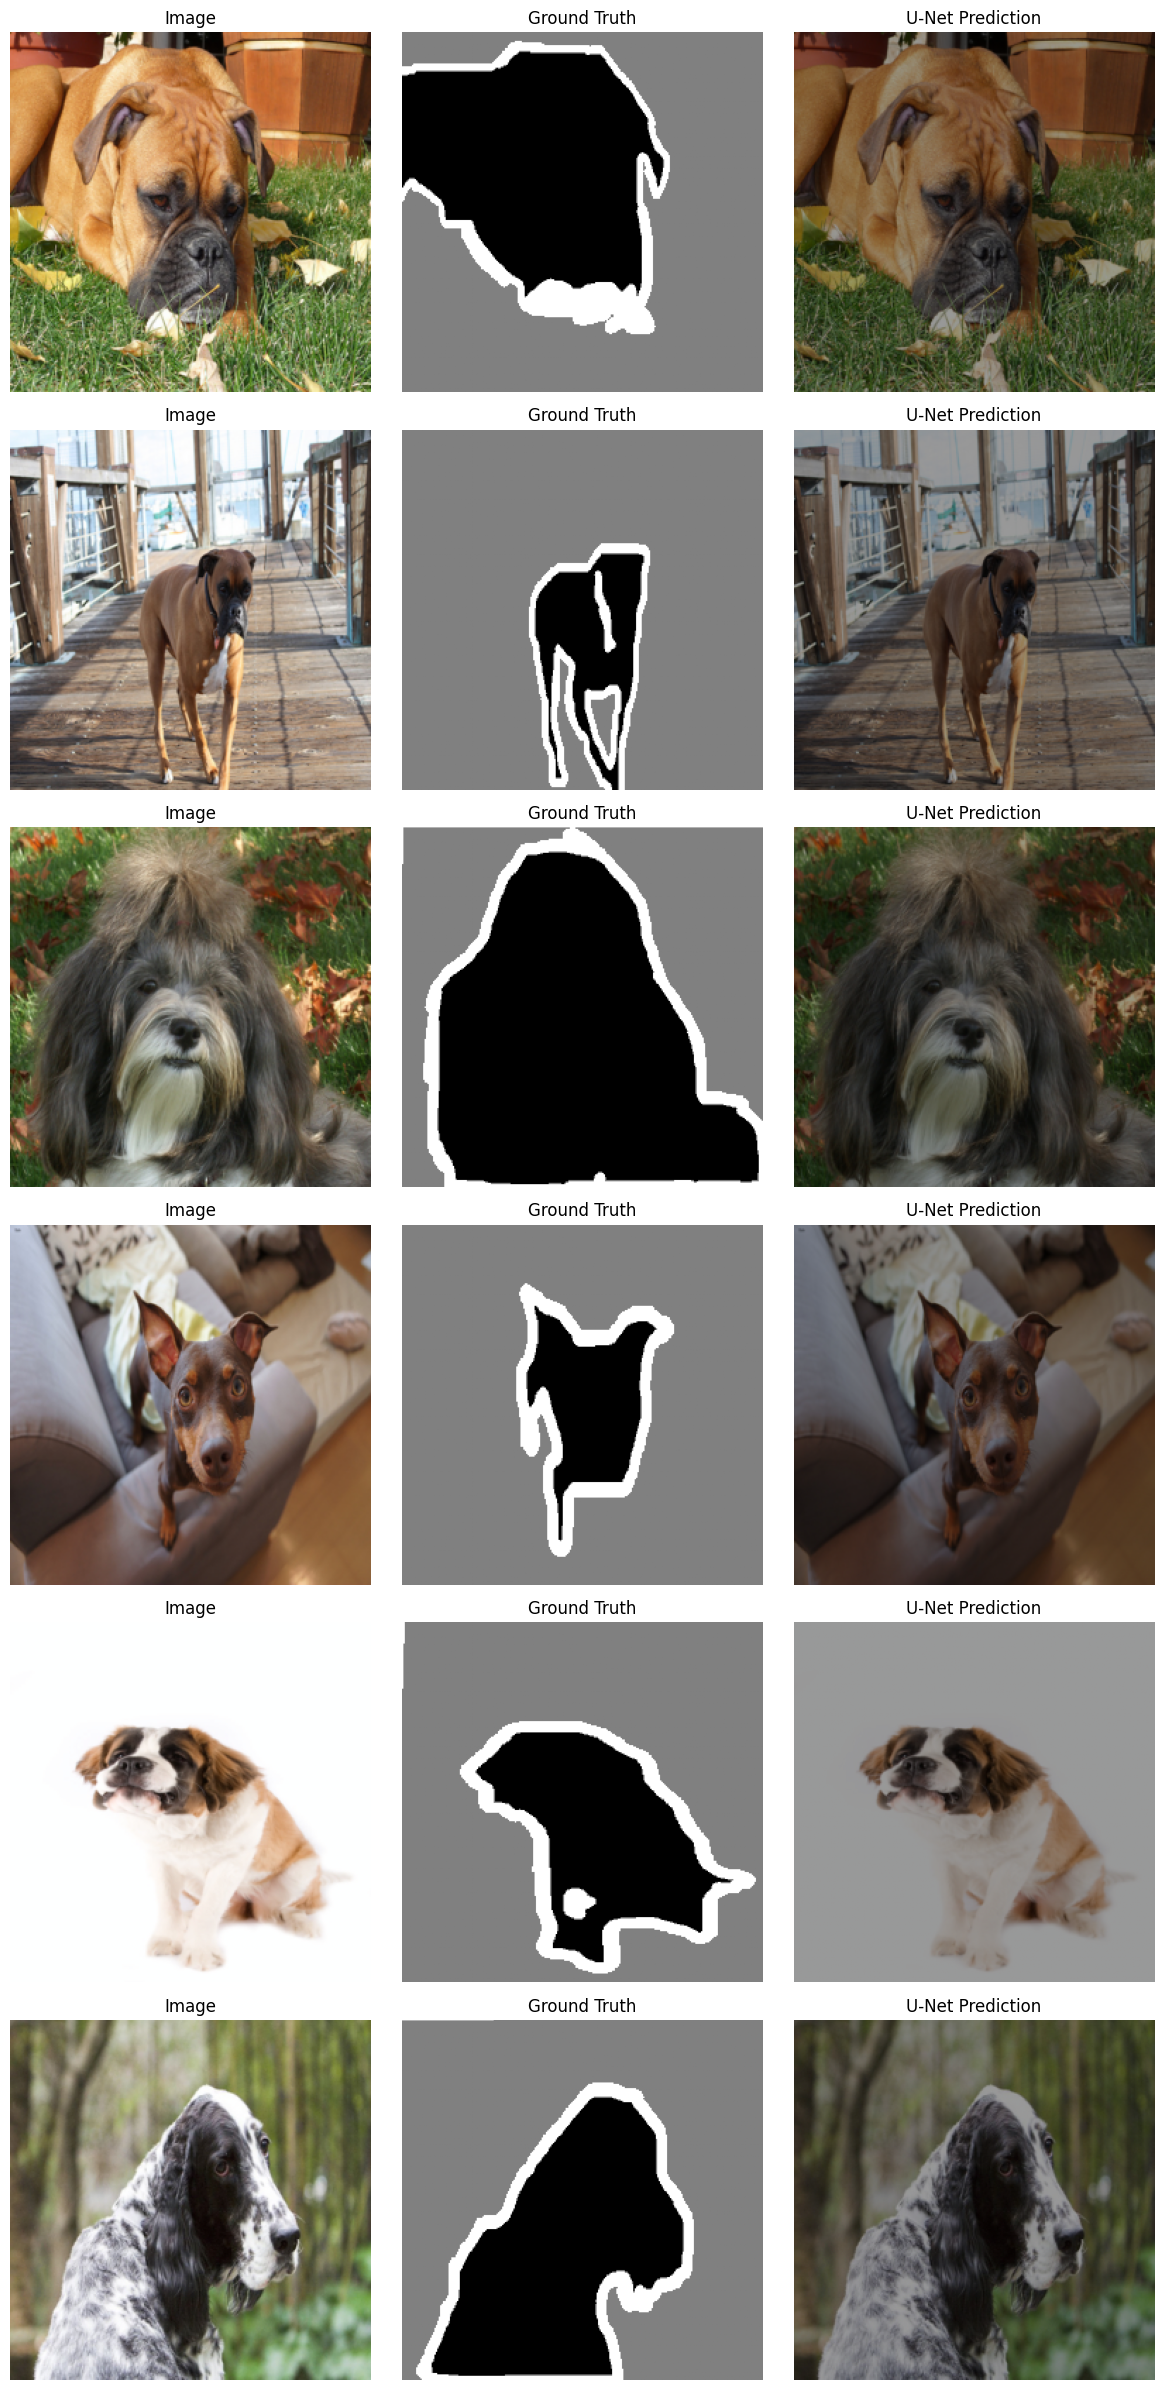

In [8]:
# -------------------------------------------------------
# 5) Visualise Predictions on a Few Validation Images
# -------------------------------------------------------

# Load the state dictionary of the best performing model from the checkpoint
model.load_state_dict(torch.load(ckpt_path, map_location=device))
model.eval()  # Set the model to evaluation mode


# Function to denormalize an image tensor
def denorm(img_t):
    # Invert the normalization used above
    # Convert tensor to numpy array and change dimension order from (C, H, W) to (H, W, C)
    img = img_t.numpy().transpose(1, 2, 0)
    # Apply inverse normalization using the mean and std used for normalization
    img = (img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])).clip(0, 1)
    return img  # Return the denormalized image (numpy array)


# Function to display sample images, ground truth masks, and model predictions
def show_samples(dataset, n=6, thr=0.5):
    # Randomly select n indices from the dataset
    idxs = np.random.choice(len(dataset), size=min(n, len(dataset)), replace=False)
    cols = 3  # Number of columns in the plot (Image, Ground Truth, Prediction)
    rows = int(np.ceil(len(idxs)))  # Number of rows in the plot (number of samples)
    plt.figure(figsize=(cols * 4, rows * 4))  # Set the figure size
    i = 1  # Initialize subplot index

    # Iterate over the selected indices
    for idx in idxs:
        img_t, mask_t = dataset[idx]   # Get image and mask tensors from the dataset
        img = denorm(img_t)            # Denormalize the image for display

        with torch.no_grad():  # Disable gradient calculation
            # Add a batch dimension to the image tensor and move to device
            logits = model(img_t.unsqueeze(0).to(device))
            pred   = (torch.sigmoid(logits) > thr).float().squeeze().cpu().numpy()

        # Create a colour overlay for the prediction mask
        overlay        = np.zeros((*pred.shape, 3))
        overlay[..., 1] = pred          # Green channel = predicted mask

        # Blend the original image with the prediction overlay
        blended = (0.6 * img + 0.4 * overlay).clip(0, 1)

        # Plot the original image
        plt.subplot(rows, cols, i); i += 1
        plt.imshow(img); plt.title("Image"); plt.axis("off")

        # Plot the ground truth mask
        plt.subplot(rows, cols, i); i += 1
        plt.imshow(mask_t.squeeze(0).numpy(), cmap="gray")
        plt.title("Ground Truth"); plt.axis("off")

        # Plot the blended image with the prediction overlay
        plt.subplot(rows, cols, i); i += 1
        plt.imshow(blended); plt.title("U-Net Prediction"); plt.axis("off")

    plt.tight_layout()  # Adjust layout to prevent overlapping titles/labels
    plt.show()          # Display the plot


# Show samples from the validation dataset
show_samples(val_ds, n=6, thr=0.5)